In [3]:
# Imports
import tensorflow as tf

import cv2
import numpy as np
import matplotlib.pyplot as plt

# For extracting file
import os
import gzip
import shutil
from pathlib import Path

In [4]:
# Essential functions

for gz_file in Path('../global-datasets/tensorflow-number-datasets').glob('*.gz'):
  output_file = gz_file.with_suffix("")
  # print(gz_file, output_file)

  with gzip.open(gz_file, 'rb') as file_in:
    with open(output_file, 'wb') as file_out:
      shutil.copyfileobj(file_in, file_out)
  
  print("Unzip: ", output_file)

def load_image(file_name):
  with open(file_name, 'rb') as f:
    magic_number = int.from_bytes(f.read(4), "big")
    image_count = int.from_bytes(f.read(4), "big")
    image_row = int.from_bytes(f.read(4), "big")
    image_col = int.from_bytes(f.read(4), "big")
    image_data = f.read()

    image = np.frombuffer(
      image_data, dtype=np.uint8
    ).reshape(
      image_count, image_row, image_col
    )
  
  return image

def load_label(file_name):
  with open(file_name, 'rb') as f:
    magic_number = int.from_bytes(f.read(4), 'big')
    count = int.from_bytes(f.read(4), 'big')
    label_data = f.read(count)
    
    label = np.frombuffer(
      label_data, dtype=np.uint8
    )

  return label

Unzip:  ..\global-datasets\tensorflow-number-datasets\t10k-images-idx3-ubyte
Unzip:  ..\global-datasets\tensorflow-number-datasets\t10k-labels-idx1-ubyte
Unzip:  ..\global-datasets\tensorflow-number-datasets\train-images-idx3-ubyte
Unzip:  ..\global-datasets\tensorflow-number-datasets\train-labels-idx1-ubyte


In [5]:
# x is data/image
# y is label

num_class = 10

x_train = load_image("../global-datasets/tensorflow-number-datasets/train-images-idx3-ubyte")
y_train = load_label("../global-datasets/tensorflow-number-datasets/train-labels-idx1-ubyte")

x_test = load_image("../global-datasets/tensorflow-number-datasets/t10k-images-idx3-ubyte")
y_test = load_label("../global-datasets/tensorflow-number-datasets/t10k-labels-idx1-ubyte")

# Normalization to make the data value between 0 - 1
x_train = x_train.astype("uint8") / 255
x_test = x_test.astype("uint8") / 255

y_train = tf.keras.utils.to_categorical(y_train, num_class)
y_test = tf.keras.utils.to_categorical(y_test, num_class)

In [6]:
# plt.imshow(x_train[0], cmap="gray")
# plt.title(y_train[0])
# plt.show()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000, 10)
(10000, 28, 28)
(10000, 10)


In [ ]:
# data = x_train[0]
# for i in data:
#   for x in i:
#     if (x > 0.05):
#       print("\x1b[31m%.1f\x1b[0m" %(x), end="") # 31m = Red
#     else:
#       print("%.1f"%(x), end="")
#   print()

# plt.imshow(data, cmap='gray')

In [ ]:
# CNN Example

input_shape = (28, 28, 1)

# Create sequential Model (Stacking)
model = tf.keras.Sequential()

# Recevie Input (28 x 28 x 1)
model.add(tf.keras.Input(shape=input_shape))

# Conv 2D
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=(5, 5), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2,2)))

# นำ layer สุดท้ายมาแผ่
model.add(tf.keras.layers.Flatten())

# Hidden Layer เพื่อทำพยากรณ์ผลลัพธ์
model.add(tf.keras.layers.Dense(200, activation="relu"))
model.add(tf.keras.layers.Dense(80, activation="relu"))
model.add(tf.keras.layers.Dense(40, activation="relu"))

# พยากรณ์ผลลัพธ์
model.add(tf.keras.layers.Dense(10, activation="softmax"))

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 200)            │       320,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 80)             │        16,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 40)             │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 359,258 (1.37 MB)

 Trainable params: 359,258 (1.37 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Training
batch_size = 10000
epoch = 10

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

history = model.fit(
  x_train,
  y_train,
  batch_size = batch_size,
  epochs = epoch,
  validation_split = 0.2
  # validation_data = (x_test, y_test)
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 17s 3s/step - accuracy: 0.3809 - loss: 2.1931 - val_accuracy: 0.5408 - val_loss: 1.9314
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6035 - loss: 1.6646 - val_accuracy: 0.7288 - val_loss: 1.1739
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7343 - loss: 0.9953 - val_accuracy: 0.7614 - val_loss: 0.7380
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7902 - loss: 0.6798 - val_accuracy: 0.8569 - val_loss: 0.4808
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8478 - loss: 0.5071 - val_accuracy: 0.8873 - val_loss: 0.3835
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8797 - loss: 0.4064 - val_accuracy: 0.9077 - val_loss: 0.3151
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9013 - loss: 0.3337 - val_accuracy: 0.9253 - val_loss: 0.2592
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.9175 - loss: 0.2780 - val_accuracy: 0.9370 - val_loss: 0.2251
Epoch 9/10
5/

In [34]:
# Predicting
num_class = 10
result_test = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


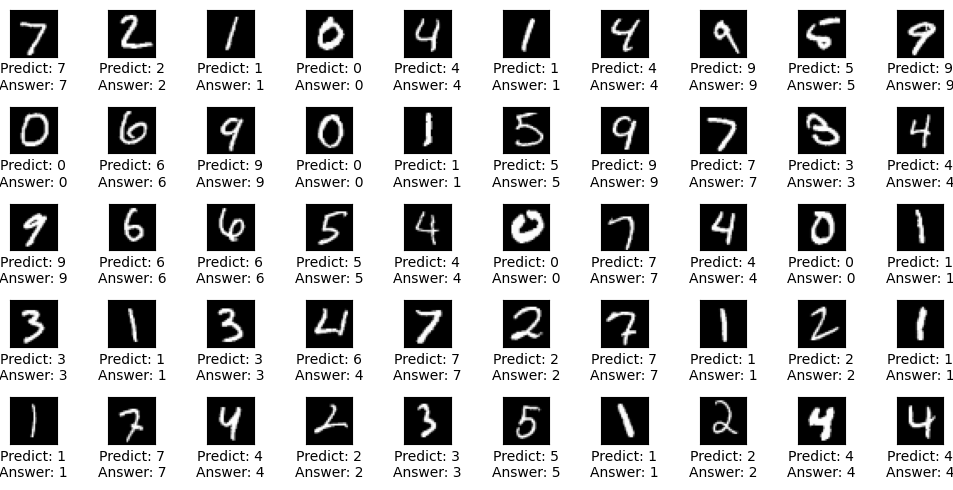

In [35]:
plt.figure(figsize=(10, 5))

for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.xticks([])
    plt.yticks([])

    pred_label = np.argmax(result_test[i])      # label ที่ model ทำนาย
    true_label = np.argmax(y_test[i])           # label จริง

    plt.xlabel(
        f"Predict: {pred_label}\n" +
        f"Answer: {true_label}"
    )
    plt.imshow(x_test[i], cmap="gray")

plt.tight_layout()

In [ ]:
print(np.argmax(result_test[3]))

0
